In [ ]:
import numpy as np;
import math as math;
import matplotlib.pyplot as plt;
from illegal_methods import import_image, get_test_images;

In [ ]:
# Image preprocessing

def preprocess(image: np.ndarray):
    image = minmax(image) # minmax normalise
    moveVector = caculate_center_of_mass_offset(image) # calculate the center of mass
    image = shift_image(image, moveVector) # move drawing so that center of mass is the image center
    image = np.resize(image, (784)) # flatten the image
    return image

def minmax(image: np.ndarray):
    maximum = np.max(image)
    return image / maximum

def caculate_center_of_mass_offset(image: np.ndarray):
    """
    Calculate the center of mass of the drawing image.
    """
    center = np.zeros((2))
    total_intensity = np.sum(image)
    for yi, y in enumerate(image):
        for xi, intensity in enumerate(y):
            center += np.array((xi, yi)) * intensity / total_intensity
    im_center = image[0].size / 2
    return center - im_center

def shift_image(image: np.ndarray, vector: np.ndarray):
    """
    Shift the values inside the image around by vector
    """
    vector = vector.astype(dtype="int8")
    vector[1] = vector[1] * image[1].size
    return np.roll(a=image, shift=vector * -1)

In [4]:
# Recognission Methods Model

def relu(arr):
    return np.maximum(0, arr)

def softmax(arr):
    arr = np.array(arr, dtype=np.float64)
    shifted = arr - np.max(arr, axis=-1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=-1, keepdims=True)

testdata = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
batch = np.array([
    [1.0, 2.0, 3.0],
    [1.0, 0.0, -1.0]
])

def forward(X, weight1, bias1, weight2, bias2) -> np.ndarray:
    Z1 = X @ weight1 + bias1
    A1 = relu(Z1)
    Z2 = A1 @ weight2 + bias2
    A2 = softmax(Z2)
    return A2



In [ ]:
# Import Recognision model

mystery_device_location = "C:/vs_studio/HR informatica/HR jaar 2/Data-Structures-And-Alogirthms/week_11_best_for_mystery/weights_biases/"
W1 = np.load(mystery_device_location + "W1.npy", allow_pickle=True)
b1 = np.load(mystery_device_location + "b1.npy", allow_pickle=True)
W2 = np.load(mystery_device_location + "W2.npy", allow_pickle=True)
b2 = np.load(mystery_device_location + "b2.npy", allow_pickle=True)

In [6]:
def recognise_batch(batch: np.ndarray):
    batch = np.array([preprocess(image) for image in batch])
    predicted = forward(batch, W1, b1, W2, b2)
    return predicted.argmax(axis=1)

In [ ]:
def recognise_file():
    """
    Recognise an image on a file path
    """
    filepath = input("Give file path: ")
    try:
        arr = import_image(filepath)

    except Exception as exception:
        print(exception)
        print("ERROR: program reverting to main menu")
        return


    if (arr.shape != (28, 28)):
        print("ERROR: image must be exactly 28 * 28 pixels")
        return

    predicted = recognise_batch([arr])[0]
    plt.title(f"Predicted: {predicted}")
    plt.imshow(arr, cmap="grey")
    plt.show()



In [ ]:

def recognise_mnist(slice: int = 200):
    """
    Determine accuracy of the model running on the mystery device based on MNIST
    """
    test_images, test_labels = get_test_images()
    predicted = recognise_batch(test_images[:slice])
    incorrect: int = 0
    print(predicted)
    for i in range(slice):
        if (predicted[i] != test_labels[i]):
            incorrect += 1

    print(f"finished recognission accuracy is {100 - incorrect / slice * 100}%")

In [8]:
recognise_mnist(9000)

[7 2 1 ... 6 9 0]
finished recognission accuracy is 97.32222222222222%


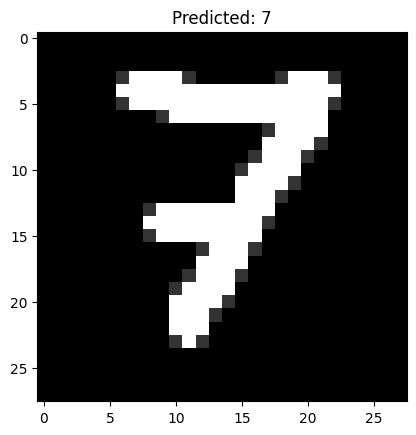

C:\Users\Rein\AppData\Local\Temp\ipykernel_11628\420621592.py:12: RuntimeWarning: invalid value encountered in divide
  return image / maximum
C:\Users\Rein\AppData\Local\Temp\ipykernel_11628\420621592.py:24: RuntimeWarning: invalid value encountered in cast
  vector = vector.astype(dtype="int8")


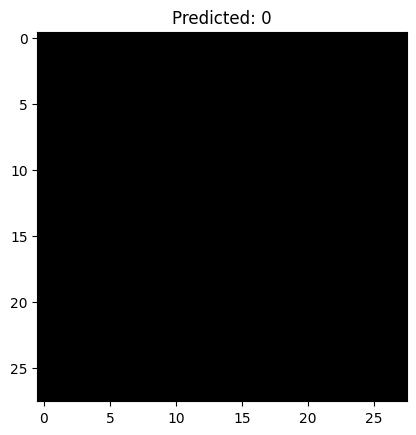

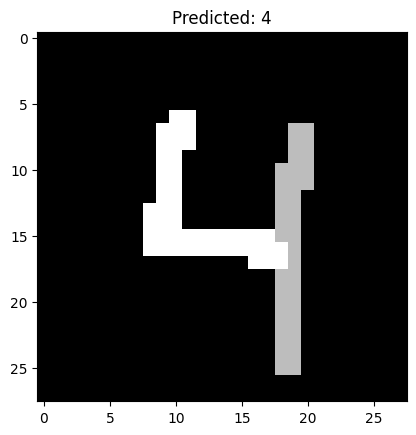

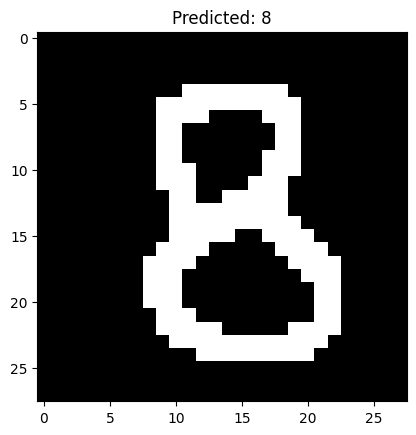

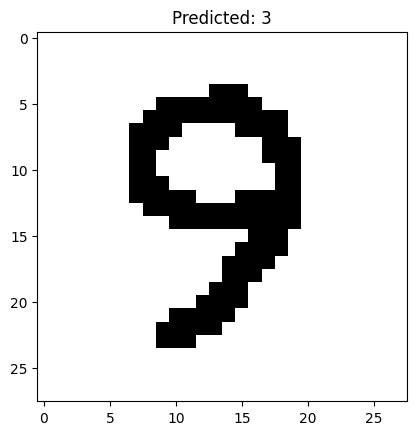

Shutting down


In [9]:
# Run loop

while (True):
    action = input("Number recognizer ultra\nOptions\n[1] recognise image from files\n[2] accuracy for mnist\n[3] quit")
    if action == "1":
        recognise_file()
    if action == "2":
        recognise_mnist()
    elif action == "3":
        print("Shutting down")
        break